In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csr_matrix, lil_matrix
from pyproj import Transformer
from sklearn.preprocessing import StandardScaler
import pyreadr 
from pathlib import Path
import os

os.chdir(Path.cwd().parent)

In [ ]:
# ================================================================
# Imports
# ================================================================
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csr_matrix, coo_matrix, bmat, diags
from sksparse.cholmod import cholesky
from polyagamma import random_polyagamma
import geopandas as gpd
import pyreadr

# ================================================================
# Load data (remove isolated points)
# ================================================================
no_nbs = np.array([
    57,170,236,269,343,685,946,947,989,
    1037,1084,1090,1109,1118,1127,1176,1203
]) - 1

snow_cleaned_full = pyreadr.read_r("snow_cleaned_full.Rda")
snow_cleaned_full = list(snow_cleaned_full.values())[0]

all_y = snow_cleaned_full.drop(index=no_nbs).reset_index(drop=True)

coords = all_y.iloc[:, :2].to_numpy()
y      = all_y.iloc[:, 2:].to_numpy()

S, TT = y.shape
period = 52

print(f"Spatial locations used (non-isolated): {S}")

# ================================================================
# Global time trend (CRITICAL: scale BEFORE subsetting)
# ================================================================
t_full = np.arange(1, TT + 1)
t_trend_full = (t_full - t_full.mean()) / t_full.std(ddof=0)

# ================================================================
# Build adjacency
# ================================================================
gdf = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(coords[:, 0], coords[:, 1]),
    crs="EPSG:4326"
)

gdf_aeqd = gdf.to_crs("+proj=aeqd +lat_0=90 +lon_0=-100")
xy = np.vstack([gdf_aeqd.geometry.x, gdf_aeqd.geometry.y]).T

dif = xy[1] - xy[2]
theta = np.arctan2(dif[1], dif[0])
R = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)]
])

rotated = (xy @ R.T) / 1e6
Distances = squareform(pdist(rotated))

Omg = (Distances <= 0.22).astype(int)
np.fill_diagonal(Omg, 0)
Omg = csr_matrix(Omg)

deg = np.array(Omg.sum(axis=1)).flatten()
assert np.all(deg > 0), "Isolated points still exist!"

# ================================================================
# ICAR precision
# ================================================================
D = diags(deg)
prec = D - Omg

# ================================================================
# MCMC settings
# ================================================================
burn = 1000
thin = 5
tot_save = 1000

a_tau = 0.01
b_tau = 0.01

# ================================================================
# BYM runner
# ================================================================
def run_bym(event_name, loc_mask, kappa_transform, save_path):

    loc = np.where(loc_mask)
    pairs = np.column_stack(loc)
    pairs = pairs[np.lexsort((pairs[:, 0], pairs[:, 1]))]
    pairs[:, 1] += 1

    row_idx  = pairs[:, 0]
    time_idx = pairs[:, 1] - 1
    N = len(row_idx)

    next_y = y[pairs[:, 0], pairs[:, 1]]
    kappa  = kappa_transform(next_y)

    # ------------------------------------------------------------
    # Time variables
    # ------------------------------------------------------------
    t_raw   = time_idx + 1              # raw time (for sin/cos)
    t_trend = t_trend_full[time_idx]    # subset ONLY

    # ------------------------------------------------------------
    # Covariates
    # ------------------------------------------------------------
    covariates = np.column_stack([
        np.ones(N), np.ones(N),
        np.cos(2*np.pi*t_raw / period),
        np.cos(2*np.pi*t_raw / period),
        np.sin(2*np.pi*t_raw / period),
        np.sin(2*np.pi*t_raw / period),
        t_trend, t_trend
    ])

    K = covariates.shape[1]
    theta_dim = K * S

    # ------------------------------------------------------------
    # Design matrix
    # ------------------------------------------------------------
    rows, cols, vals = [], [], []
    for i in tqdm(range(N), desc=f"Design {event_name}"):
        s = row_idx[i]
        for k in range(K):
            rows.append(i)
            cols.append(s + k*S)
            vals.append(covariates[i, k])

    X = coo_matrix((vals, (rows, cols)), shape=(N, theta_dim)).tocsr()

    # ------------------------------------------------------------
    # Storage
    # ------------------------------------------------------------
    total_iters = burn + tot_save * thin
    all_theta = np.zeros((theta_dim, tot_save))
    all_tau   = np.zeros((K, tot_save))

    curr_theta = np.zeros(theta_dim)
    curr_tau   = np.ones(K)

    save_idx = 0

    # ------------------------------------------------------------
    # MCMC
    # ------------------------------------------------------------
    for it in tqdm(range(total_iters), desc=f"MCMC {event_name}"):

        phi = X @ curr_theta
        omega = random_polyagamma(1, phi, size=N)

        block_list = []
        for j in range(K):
            if j % 2 == 0:
                block_list.append((1 / curr_tau[j]) * prec)
            else:
                block_list.append((1 / curr_tau[j]) * diags(np.ones(S)))

        blocks = [[block_list[i] if i == j else None for j in range(K)]
                  for i in range(K)]
        curr_prec = bmat(blocks, format="csr")

        XtOmega = X.T.multiply(omega)
        post_prec = XtOmega @ X + curr_prec

        factor = cholesky(post_prec)
        mu = factor.solve_A(X.T @ kappa)
        curr_theta = mu + factor.solve_A(np.random.randn(theta_dim))

        for j in range(K):
            sl = slice(j*S, (j+1)*S)
            beta = curr_theta[sl]
            quad = beta @ (prec @ beta) if j % 2 == 0 else beta @ beta
            curr_tau[j] = 1 / np.random.gamma(
                a_tau + S/2,
                1 / (b_tau + quad/2)
            )

        if it >= burn and (it - burn) % thin == 0:
            all_theta[:, save_idx] = curr_theta
            all_tau[:, save_idx]   = curr_tau
            save_idx += 1
            if save_idx == tot_save:
                break

    np.savez_compressed(save_path, all_theta=all_theta, all_tau=all_tau)

# ================================================================
# Run p01
# ================================================================
run_bym(
    "p01",
    loc_mask=(y[:, :-1] == 0),
    kappa_transform=lambda ny: ny - 0.5,
    save_path=r"D:\77\Research\temp\snow\bym01_noIso_final.npz"
)

# ================================================================
# Run p10
# ================================================================
run_bym(
    "p10",
    loc_mask=(y[:, :-1] == 1),
    kappa_transform=lambda ny: (1 - ny) - 0.5,
    save_path=r"D:\77\Research\temp\snow\bym10_noIso_final.npz"
)


Spatial locations used (non-isolated): 1601


MCMC p01:   0%|          | 0/6000 [00:00<?, ?it/s]C:\Users\lix23\AppData\Local\Temp\ipykernel_4256\2986998580.py:170: CholmodTypeConversionWarning: converting matrix of class csr_matrix to CSC format
  factor = cholesky(post_prec)
MCMC p10: 100%|█████████▉| 5995/6000 [2:34:47<00:07,  1.55s/it]  


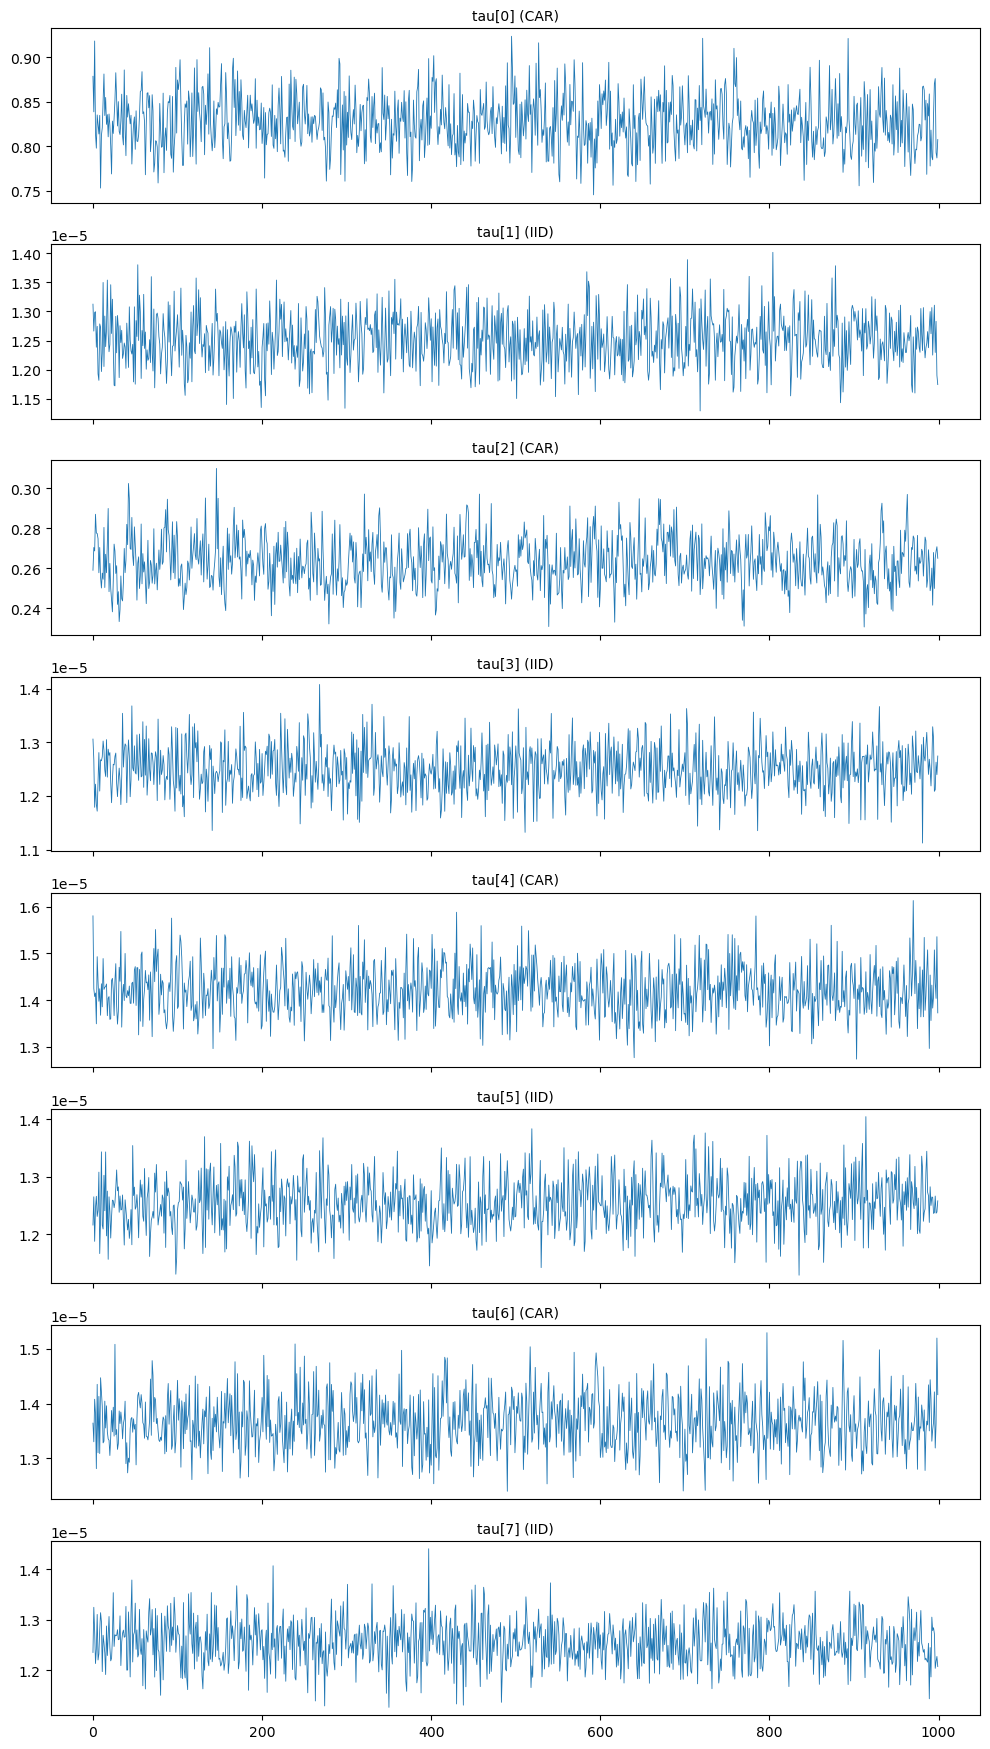

In [3]:
import numpy as np
import matplotlib.pyplot as plt

res = np.load(r"D:\77\Research\temp\snow\bym01_noIso_final.npz")
all_tau = res["all_tau"]   # shape (K, tot_save)

K = all_tau.shape[0]

fig, axes = plt.subplots(K, 1, figsize=(10, 2.2*K), sharex=True)

for j in range(K):
    ax = axes[j]
    ax.plot(all_tau[j], lw=0.6)
    kind = "CAR" if j % 2 == 0 else "IID"
    ax.set_title(f"tau[{j}] ({kind})", fontsize=10)

plt.tight_layout()
plt.show()


Inferred S = 1601
Picked spatial indices: [1073  326 1558  918  974]


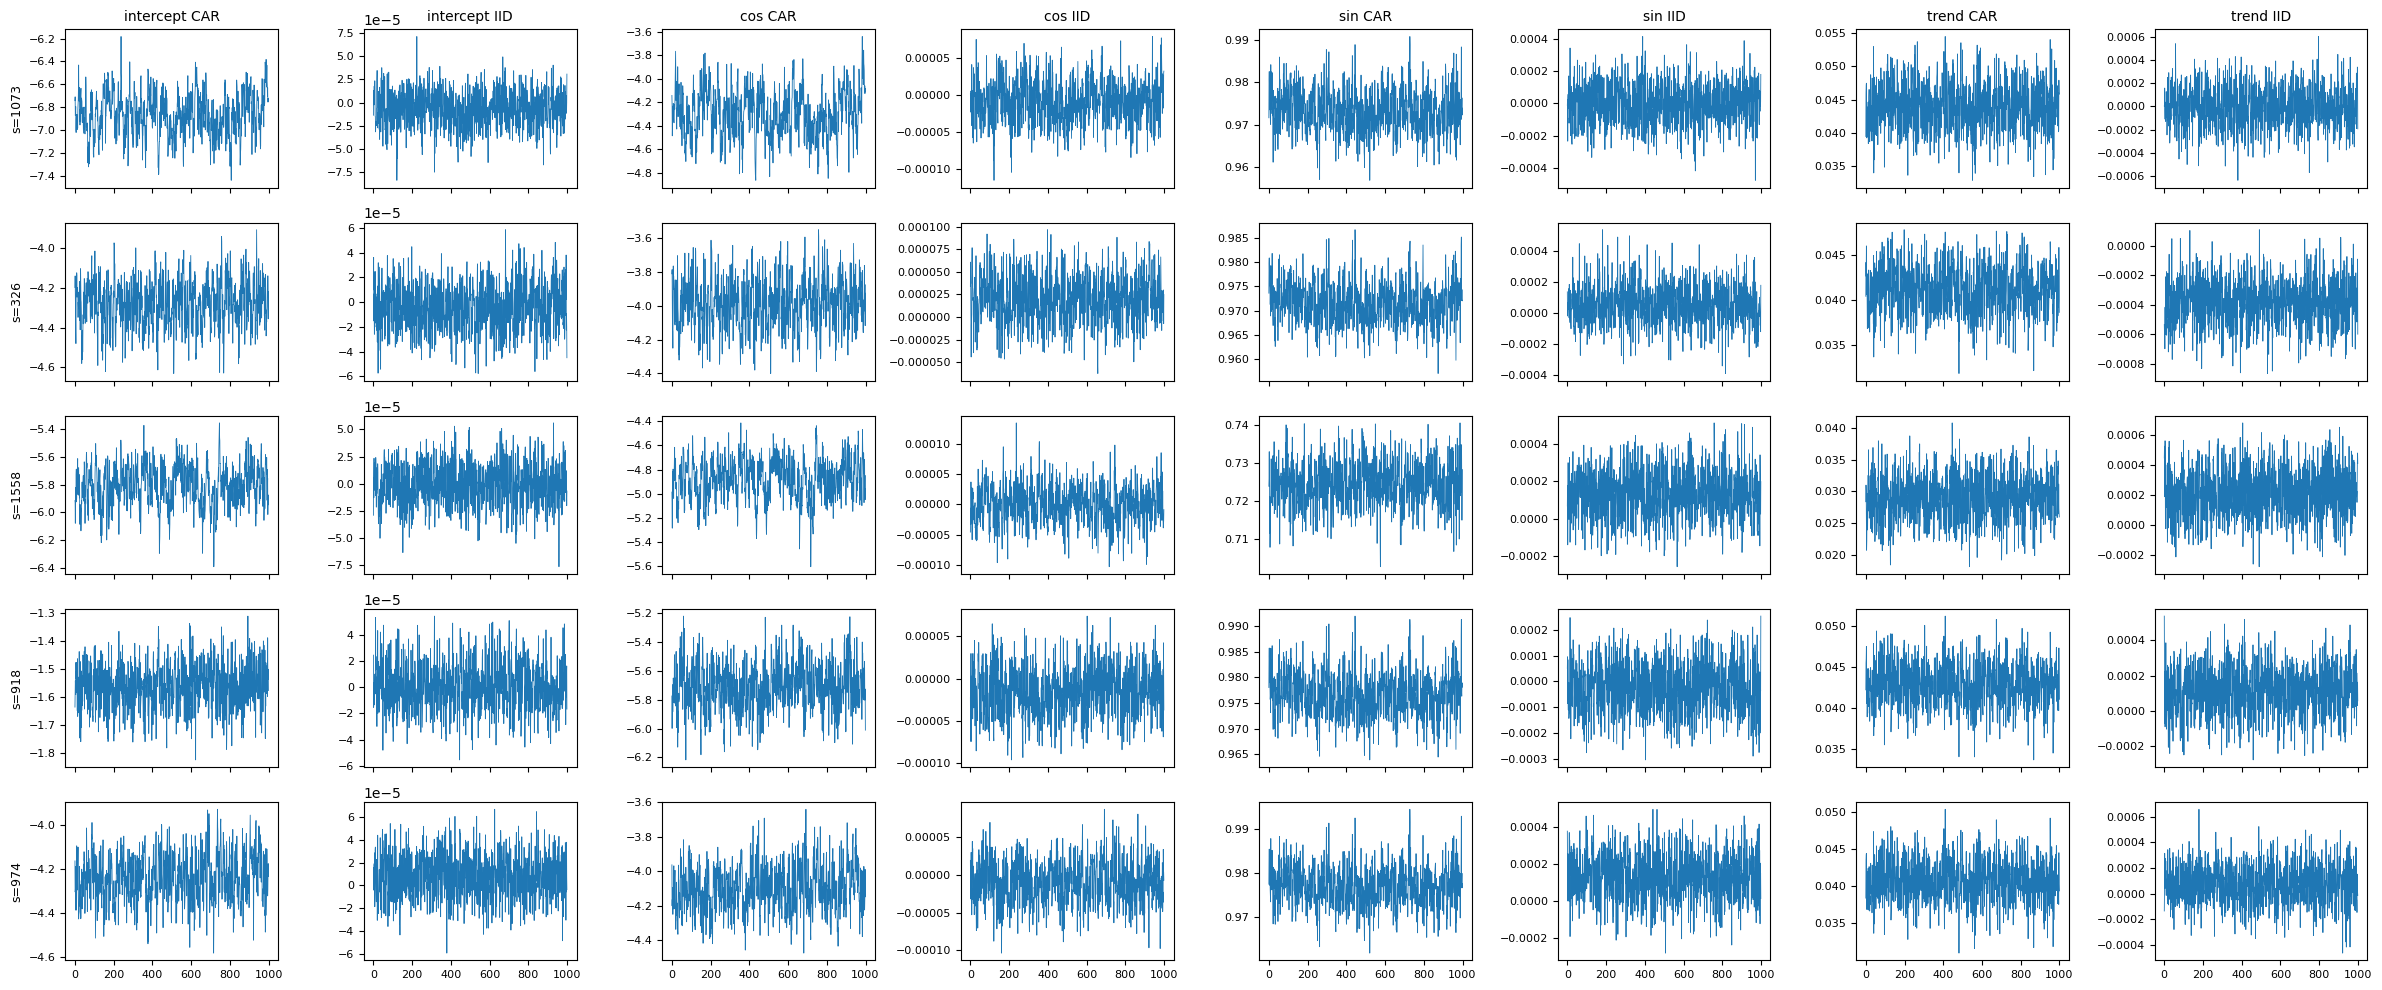

0 0.8127807955080183
2 0.2683022213074744
4 1.9459208644985273e-06
6 1.2682161467664576e-06


In [4]:
import numpy as np
import matplotlib.pyplot as plt

res = np.load(r"D:\77\Research\temp\snow\bym01_noIso_final.npz")
all_theta = res["all_theta"]

theta_dim, Tsave = all_theta.shape
K = 8

assert theta_dim % K == 0, "theta_dim is not divisible by K!"

S = theta_dim // K
print(f"Inferred S = {S}")


assert theta_dim == K * S

# ============================================================
# Randomly pick 5 spatial locations
# ============================================================
np.random.seed(0)
picked_s = np.random.choice(S, size=5, replace=False)

print("Picked spatial indices:", picked_s)

# ============================================================
# Plot traceplots
# ============================================================
fig, axes = plt.subplots(
    nrows=5, ncols=K,
    figsize=(3.0*K, 2.0*5),
    sharex=True
)

names = [
    "intercept CAR", "intercept IID",
    "cos CAR",       "cos IID",
    "sin CAR",       "sin IID",
    "trend CAR",     "trend IID"
]

for i, s in enumerate(picked_s):
    for j in range(K):
        ax = axes[i, j]

        idx = s + j * S        
        ax.plot(all_theta[idx], lw=0.6)

        if i == 0:
            ax.set_title(names[j], fontsize=10)

        if j == 0:
            ax.set_ylabel(f"s={s}", fontsize=9)

        ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()
for j in [0,2,4,6]:
    beta = all_theta[j*S:(j+1)*S, -1]
    quad = beta @ (prec @ beta)
    print(j, quad / S)
